<a href="https://colab.research.google.com/github/thuynguyenhuit/hocsau/blob/main/MLP_CreditCard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#1. Kết nối dữ liệu trên drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE


Dữ liệu đã tải thành công:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class
0    284315
1       492
Name: count, dtype: int64


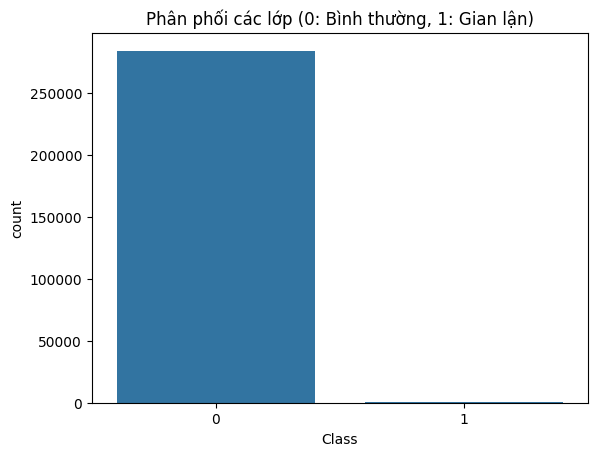

In [4]:
import pandas as pd

# Đường dẫn đến file creditcard.csv trên Drive của bạn
# Ví dụ: file nằm ngay ngoài Drive thì đường dẫn là '/content/drive/MyDrive/creditcard.csv'
file_path = '/content/drive/MyDrive/MLP/creditcard.csv'

# Đọc file
df = pd.read_csv(file_path)

# Kiểm tra 5 dòng đầu tiên
print("Dữ liệu đã tải thành công:")
display(df.head())
#Kiểm tra sự mất cân bằng dữ liệu
import matplotlib.pyplot as plt
import seaborn as sns

# Xem số lượng mẫu của mỗi lớp
print(df['Class'].value_counts())

# Vẽ biểu đồ trực quan
sns.countplot(x='Class', data=df)
plt.title('Phân phối các lớp (0: Bình thường, 1: Gian lận)')
plt.show()

--- Đang tải và chuẩn hóa dữ liệu ---
--- Đang thực hiện SMOTE (sampling_strategy=0.2) ---

Bắt đầu huấn luyện: KHÔNG SMOTE

Bắt đầu huấn luyện: CÓ SMOTE (0.2)


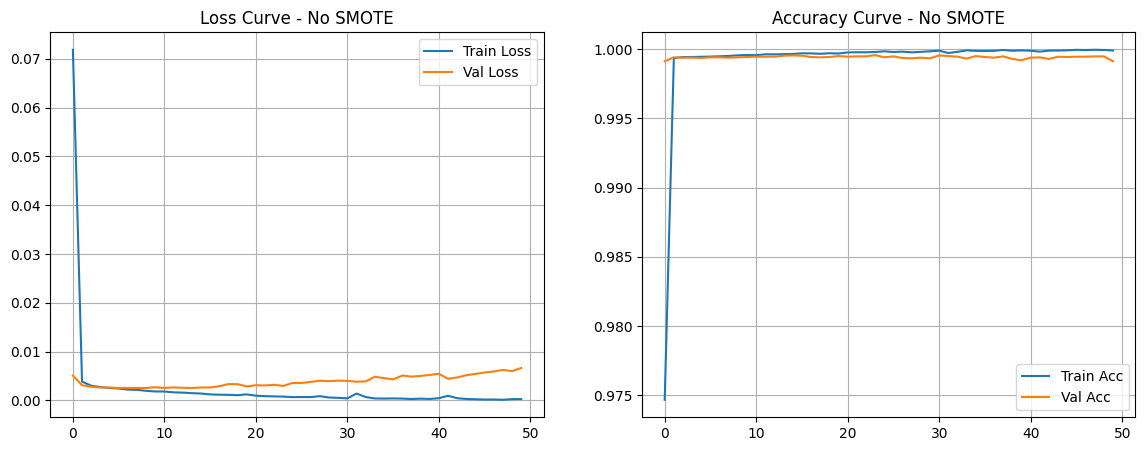

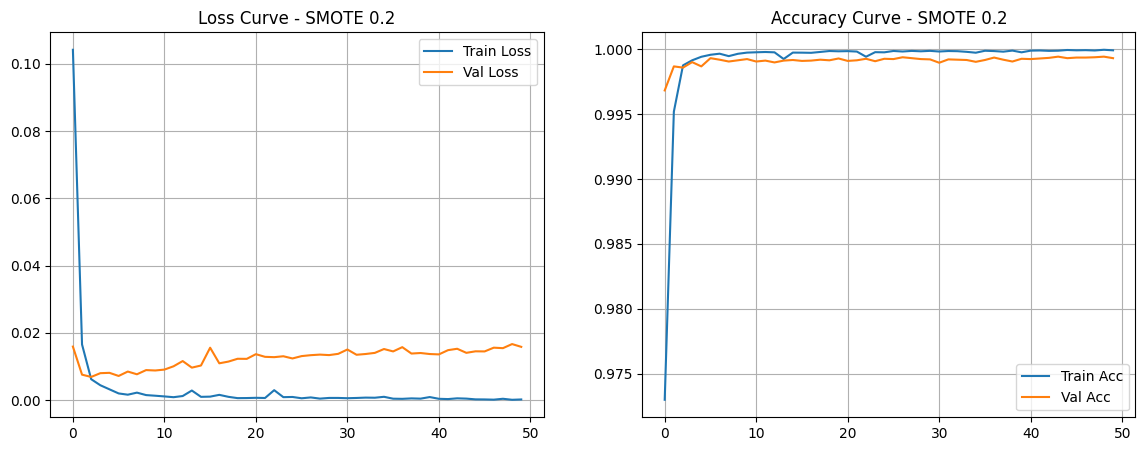


--- BÁO CÁO: KHÔNG SMOTE ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.74      0.76      0.75        74

    accuracy                           1.00     42722
   macro avg       0.87      0.88      0.87     42722
weighted avg       1.00      1.00      1.00     42722


--- BÁO CÁO: CÓ SMOTE (0.2) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.77      0.78      0.78        74

    accuracy                           1.00     42722
   macro avg       0.89      0.89      0.89     42722
weighted avg       1.00      1.00      1.00     42722



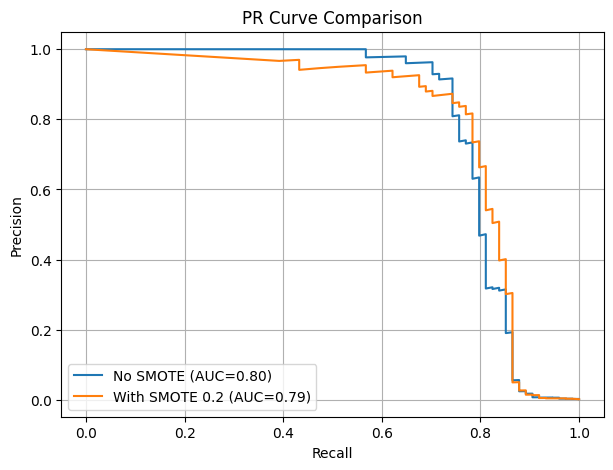

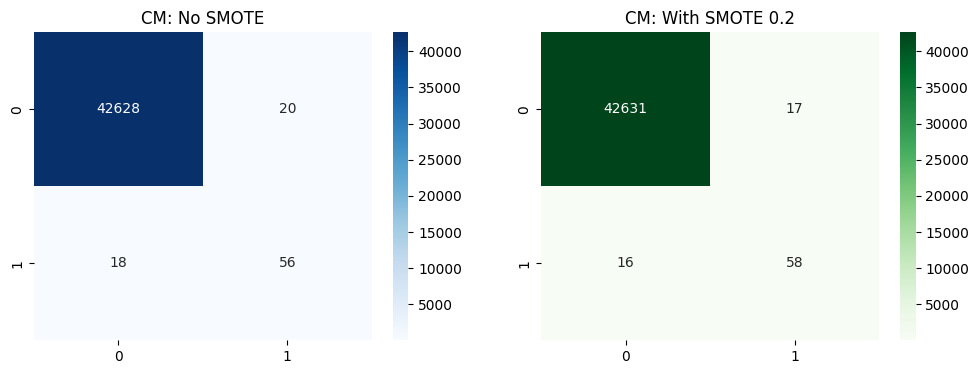

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE

# ==========================================
# 1. TIỀN XỬ LÝ DỮ LIỆU
# ==========================================
print("--- Đang tải và chuẩn hóa dữ liệu ---")
file_path = '/content/drive/MyDrive/MLP/creditcard.csv'
df = pd.read_csv(file_path)

scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

X = df.drop('Class', axis=1).values
y = df['Class'].values

# Chia tập Train (70%), Validation (15%), Test (15%)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.176, random_state=42, stratify=y_train_full)

# Trường hợp 1: Không dùng SMOTE
# Trường hợp 2: Dùng SMOTE tỉ lệ 0.2
print("--- Đang thực hiện SMOTE (sampling_strategy=0.2) ---")
sm = SMOTE(sampling_strategy=0.2, random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

# ==========================================
# 2. KIẾN TRÚC MÔ HÌNH MLP (KHÔNG CÓ DROPOUT)
# ==========================================
import torch.nn as nn

class CreditCardMLP(nn.Module):
    def __init__(self, input_size):
        super(CreditCardMLP, self).__init__()
        self.net = nn.Sequential(
            # Lớp ẩn thứ 1: input_size -> 256
            nn.Linear(input_size, 256),
            nn.ReLU(),

            # Lớp ẩn thứ 2: 256 -> 128
            nn.Linear(256, 128),
            nn.ReLU(),

            # Lớp ẩn thứ 3: 128 -> 64
            nn.Linear(128, 64),
            nn.ReLU(),

            # Lớp đầu ra (Output layer): 64 -> 2
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)

# ==========================================
# 3. HÀM HUẤN LUYỆN (Training Loop)
# ==========================================
def train_and_track(X_tr, y_tr, X_v, y_v, title):
    print(f"\nBắt đầu huấn luyện: {title}")
    # Chuyển đổi dữ liệu sang Tensor
    X_tr_t, y_tr_t = torch.FloatTensor(X_tr), torch.LongTensor(y_tr)
    X_v_t, y_v_t = torch.FloatTensor(X_v), torch.LongTensor(y_v)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=2048, shuffle=True)
    model = CreditCardMLP(X_tr.shape[1])
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    history = {'t_loss': [], 'v_loss': [], 't_acc': [], 'v_acc': []}

    for epoch in range(50):
        model.train()
        correct, total, epoch_loss = 0, 0, 0
        for inputs, labels in loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # Pha Validation
        model.eval()
        with torch.no_grad():
            v_outputs = model(X_v_t)
            v_loss = criterion(v_outputs, y_v_t)
            _, v_pred = torch.max(v_outputs.data, 1)
            v_correct = (v_pred == y_v_t).sum().item()

        history['t_loss'].append(epoch_loss/len(loader))
        history['v_loss'].append(v_loss.item())
        history['t_acc'].append(correct/total)
        history['v_acc'].append(v_correct/len(y_v))

    return model, history

# ==========================================
# 4. THỰC THI HUẤN LUYỆN 2 TRƯỜNG HỢP
# ==========================================
model_no, hist_no = train_and_track(X_train, y_train, X_val, y_val, "KHÔNG SMOTE")
model_sm, hist_sm = train_and_track(X_train_smote, y_train_smote, X_val, y_val, "CÓ SMOTE (0.2)")

# ==========================================
# 5. TRỰC QUAN HÓA (Đầy đủ yêu cầu)
# ==========================================
def plot_results(hist, title_suffix):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    # Biểu đồ Loss
    ax[0].plot(hist['t_loss'], label='Train Loss')
    ax[0].plot(hist['v_loss'], label='Val Loss')
    ax[0].set_title(f'Loss Curve - {title_suffix}')
    ax[0].legend(); ax[0].grid(True)
    # Biểu đồ Accuracy
    ax[1].plot(hist['t_acc'], label='Train Acc')
    ax[1].plot(hist['v_acc'], label='Val Acc')
    ax[1].set_title(f'Accuracy Curve - {title_suffix}')
    ax[1].legend(); ax[1].grid(True)
    plt.show()

plot_results(hist_no, "No SMOTE")
plot_results(hist_sm, "SMOTE 0.2")

# ==========================================
# 6. ĐÁNH GIÁ VÀ SO SÁNH TRÊN TẬP TEST
# ==========================================
def evaluate(model, title):
    model.eval()
    with torch.no_grad():
        outputs = model(torch.FloatTensor(X_test))
        y_probas = torch.softmax(outputs, dim=1)[:, 1].numpy()
        y_pred = np.argmax(outputs.numpy(), axis=1)

    print(f"\n--- {title} ---")
    print(classification_report(y_test, y_pred))

    # Precision-Recall Curve
    p, r, _ = precision_recall_curve(y_test, y_probas)
    return p, r, auc(r, p), confusion_matrix(y_test, y_pred)

p_no, r_no, auc_no, cm_no = evaluate(model_no, "BÁO CÁO: KHÔNG SMOTE")
p_sm, r_sm, auc_sm, cm_sm = evaluate(model_sm, "BÁO CÁO: CÓ SMOTE (0.2)")

# Vẽ so sánh PR Curve và Confusion Matrix
plt.figure(figsize=(7, 5))
plt.plot(r_no, p_no, label=f'No SMOTE (AUC={auc_no:.2f})')
plt.plot(r_sm, p_sm, label=f'With SMOTE 0.2 (AUC={auc_sm:.2f})')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('PR Curve Comparison')
plt.legend(); plt.grid(True); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm_no, annot=True, fmt='d', cmap='Blues', ax=ax[0]); ax[0].set_title("CM: No SMOTE")
sns.heatmap(cm_sm, annot=True, fmt='d', cmap='Greens', ax=ax[1]); ax[1].set_title("CM: With SMOTE 0.2")
plt.show()

--- Đang tải và chuẩn hóa dữ liệu ---
--- Đang thực hiện SMOTE (sampling_strategy=0.5) ---

Bắt đầu huấn luyện: KHÔNG SMOTE

Bắt đầu huấn luyện: CÓ SMOTE (0.5)


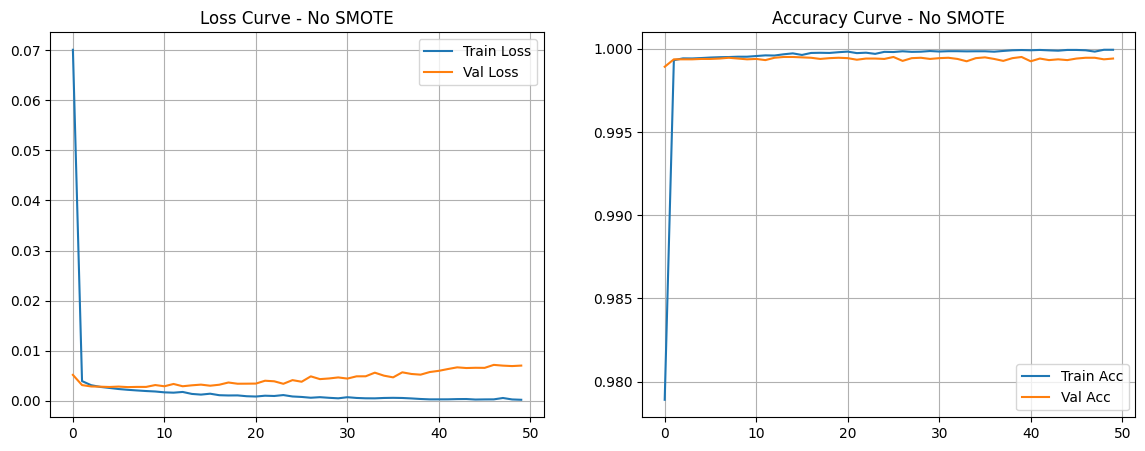

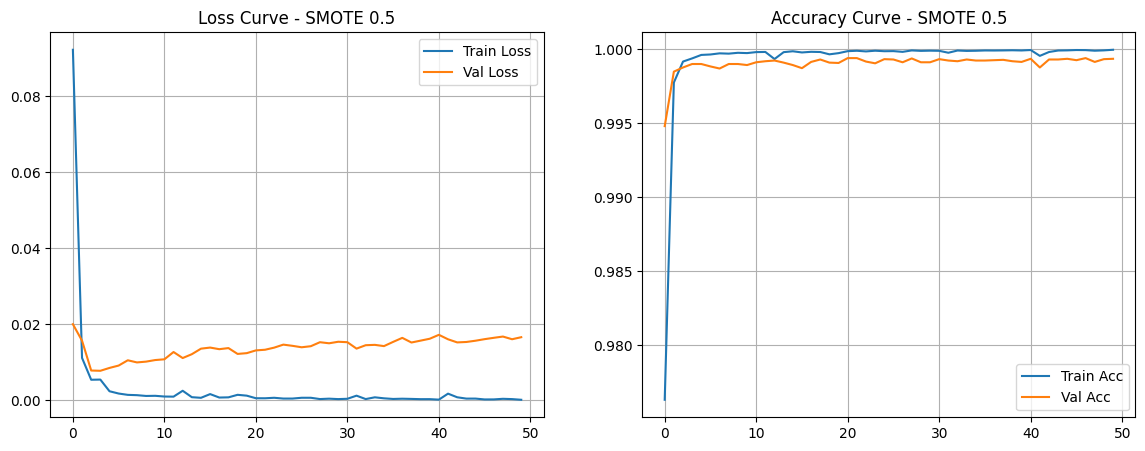


--- BÁO CÁO: KHÔNG SMOTE ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.89      0.78      0.83        74

    accuracy                           1.00     42722
   macro avg       0.95      0.89      0.92     42722
weighted avg       1.00      1.00      1.00     42722


--- BÁO CÁO: CÓ SMOTE (0.5) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.81      0.78      0.79        74

    accuracy                           1.00     42722
   macro avg       0.90      0.89      0.90     42722
weighted avg       1.00      1.00      1.00     42722



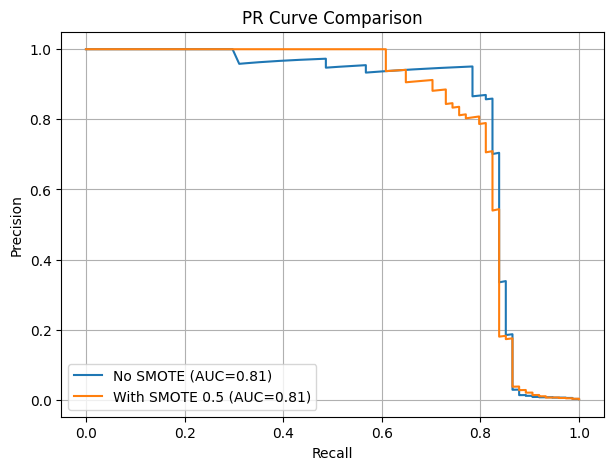

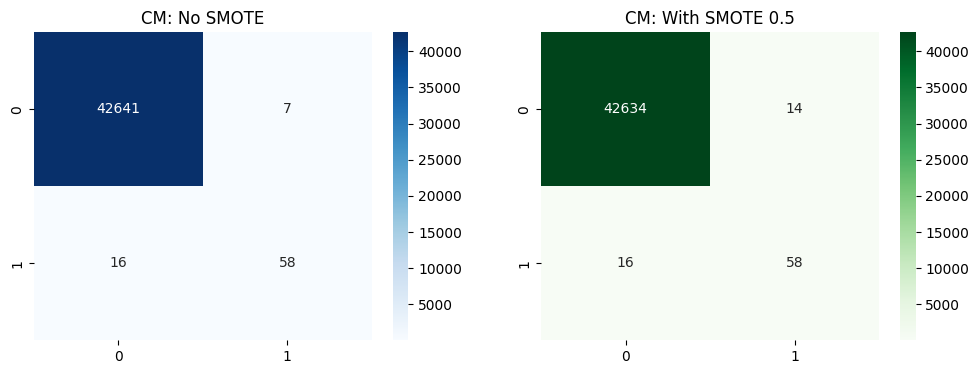

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE

# ==========================================
# 1. TIỀN XỬ LÝ DỮ LIỆU
# ==========================================
print("--- Đang tải và chuẩn hóa dữ liệu ---")
file_path = '/content/drive/MyDrive/MLP/creditcard.csv'
df = pd.read_csv(file_path)

scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

X = df.drop('Class', axis=1).values
y = df['Class'].values

# Chia tập Train (70%), Validation (15%), Test (15%)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.176, random_state=42, stratify=y_train_full)

# Trường hợp 1: Không dùng SMOTE
# Trường hợp 2: Dùng SMOTE tỉ lệ 0.5
print("--- Đang thực hiện SMOTE (sampling_strategy=0.5) ---")
sm = SMOTE(sampling_strategy=0.5, random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

# ==========================================
# 2. KIẾN TRÚC MÔ HÌNH MLP (KHÔNG CÓ DROPOUT)
# ==========================================
import torch.nn as nn

class CreditCardMLP(nn.Module):
    def __init__(self, input_size):
        super(CreditCardMLP, self).__init__()
        self.net = nn.Sequential(
            # Lớp ẩn thứ 1: input_size -> 256
            nn.Linear(input_size, 256),
            nn.ReLU(),

            # Lớp ẩn thứ 2: 256 -> 128
            nn.Linear(256, 128),
            nn.ReLU(),

            # Lớp ẩn thứ 3: 128 -> 64
            nn.Linear(128, 64),
            nn.ReLU(),

            # Lớp đầu ra (Output layer): 64 -> 2
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)

# ==========================================
# 3. HÀM HUẤN LUYỆN (Training Loop)
# ==========================================
def train_and_track(X_tr, y_tr, X_v, y_v, title):
    print(f"\nBắt đầu huấn luyện: {title}")
    # Chuyển đổi dữ liệu sang Tensor
    X_tr_t, y_tr_t = torch.FloatTensor(X_tr), torch.LongTensor(y_tr)
    X_v_t, y_v_t = torch.FloatTensor(X_v), torch.LongTensor(y_v)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=2048, shuffle=True)
    model = CreditCardMLP(X_tr.shape[1])
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    history = {'t_loss': [], 'v_loss': [], 't_acc': [], 'v_acc': []}

    for epoch in range(50):
        model.train()
        correct, total, epoch_loss = 0, 0, 0
        for inputs, labels in loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # Pha Validation
        model.eval()
        with torch.no_grad():
            v_outputs = model(X_v_t)
            v_loss = criterion(v_outputs, y_v_t)
            _, v_pred = torch.max(v_outputs.data, 1)
            v_correct = (v_pred == y_v_t).sum().item()

        history['t_loss'].append(epoch_loss/len(loader))
        history['v_loss'].append(v_loss.item())
        history['t_acc'].append(correct/total)
        history['v_acc'].append(v_correct/len(y_v))

    return model, history

# ==========================================
# 4. THỰC THI HUẤN LUYỆN 2 TRƯỜNG HỢP
# ==========================================
model_no, hist_no = train_and_track(X_train, y_train, X_val, y_val, "KHÔNG SMOTE")
model_sm, hist_sm = train_and_track(X_train_smote, y_train_smote, X_val, y_val, "CÓ SMOTE (0.5)")

# ==========================================
# 5. TRỰC QUAN HÓA (Đầy đủ yêu cầu)
# ==========================================
def plot_results(hist, title_suffix):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    # Biểu đồ Loss
    ax[0].plot(hist['t_loss'], label='Train Loss')
    ax[0].plot(hist['v_loss'], label='Val Loss')
    ax[0].set_title(f'Loss Curve - {title_suffix}')
    ax[0].legend(); ax[0].grid(True)
    # Biểu đồ Accuracy
    ax[1].plot(hist['t_acc'], label='Train Acc')
    ax[1].plot(hist['v_acc'], label='Val Acc')
    ax[1].set_title(f'Accuracy Curve - {title_suffix}')
    ax[1].legend(); ax[1].grid(True)
    plt.show()

plot_results(hist_no, "No SMOTE")
plot_results(hist_sm, "SMOTE 0.5")

# ==========================================
# 6. ĐÁNH GIÁ VÀ SO SÁNH TRÊN TẬP TEST
# ==========================================
def evaluate(model, title):
    model.eval()
    with torch.no_grad():
        outputs = model(torch.FloatTensor(X_test))
        y_probas = torch.softmax(outputs, dim=1)[:, 1].numpy()
        y_pred = np.argmax(outputs.numpy(), axis=1)

    print(f"\n--- {title} ---")
    print(classification_report(y_test, y_pred))

    # Precision-Recall Curve
    p, r, _ = precision_recall_curve(y_test, y_probas)
    return p, r, auc(r, p), confusion_matrix(y_test, y_pred)

p_no, r_no, auc_no, cm_no = evaluate(model_no, "BÁO CÁO: KHÔNG SMOTE")
p_sm, r_sm, auc_sm, cm_sm = evaluate(model_sm, "BÁO CÁO: CÓ SMOTE (0.5)")

# Vẽ so sánh PR Curve và Confusion Matrix
plt.figure(figsize=(7, 5))
plt.plot(r_no, p_no, label=f'No SMOTE (AUC={auc_no:.2f})')
plt.plot(r_sm, p_sm, label=f'With SMOTE 0.5 (AUC={auc_sm:.2f})')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('PR Curve Comparison')
plt.legend(); plt.grid(True); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm_no, annot=True, fmt='d', cmap='Blues', ax=ax[0]); ax[0].set_title("CM: No SMOTE")
sns.heatmap(cm_sm, annot=True, fmt='d', cmap='Greens', ax=ax[1]); ax[1].set_title("CM: With SMOTE 0.5")
plt.show()

--- Đang tải và chuẩn hóa dữ liệu ---
--- Đang thực hiện SMOTE (sampling_strategy=0.8) ---

Bắt đầu huấn luyện: KHÔNG SMOTE

Bắt đầu huấn luyện: CÓ SMOTE (0.8)


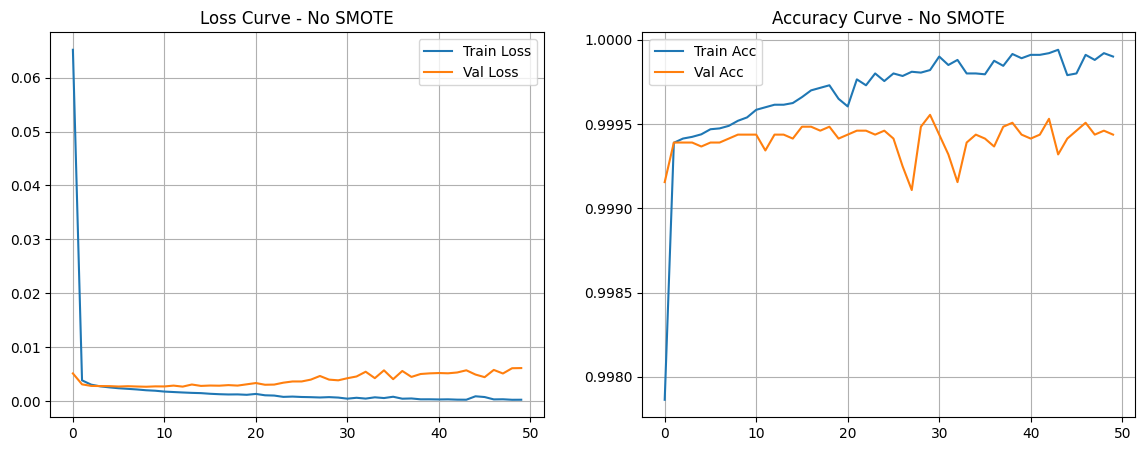

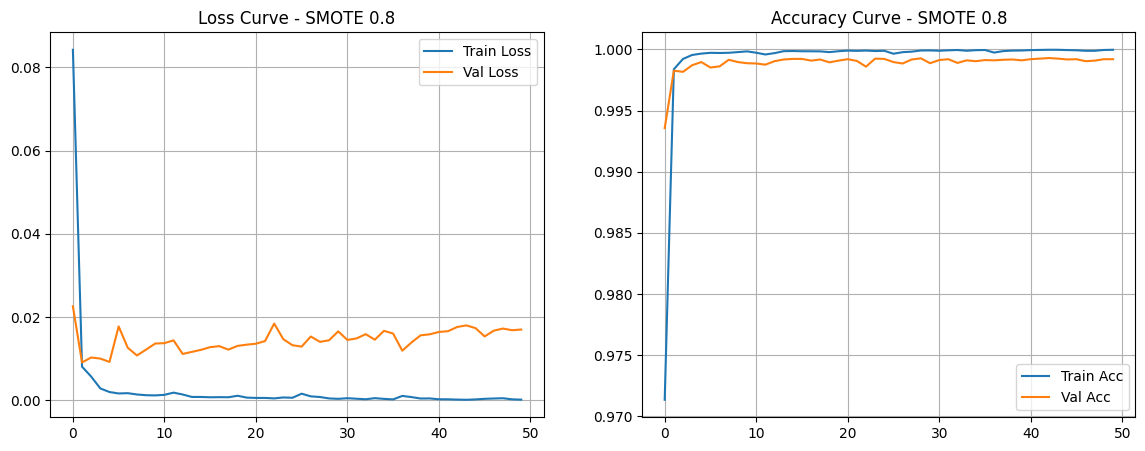


--- BÁO CÁO: KHÔNG SMOTE ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.85      0.78      0.82        74

    accuracy                           1.00     42722
   macro avg       0.93      0.89      0.91     42722
weighted avg       1.00      1.00      1.00     42722


--- BÁO CÁO: CÓ SMOTE (0.8) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.77      0.80      0.78        74

    accuracy                           1.00     42722
   macro avg       0.88      0.90      0.89     42722
weighted avg       1.00      1.00      1.00     42722



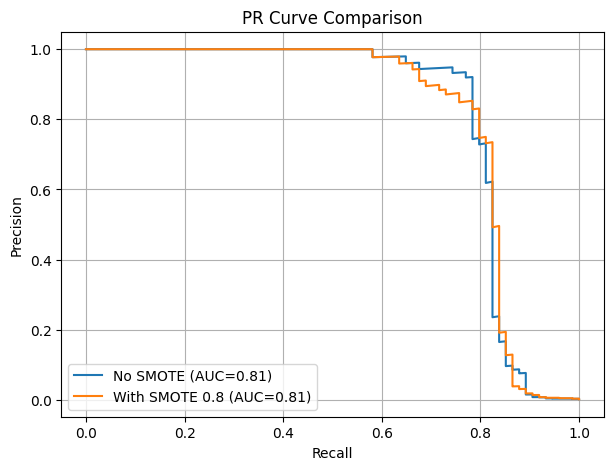

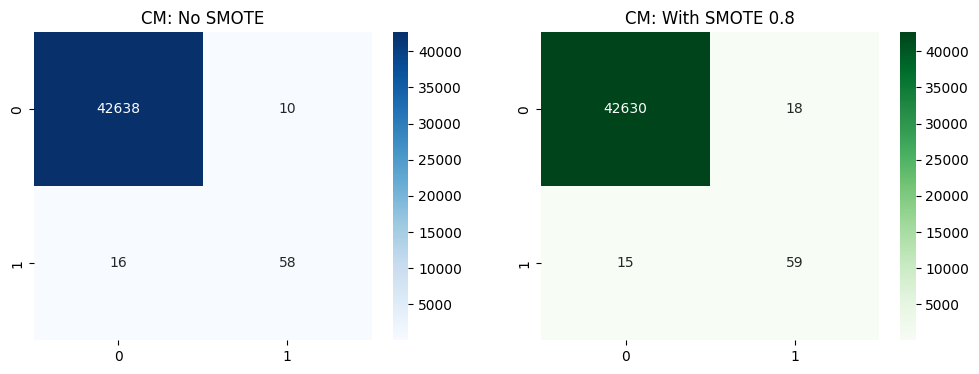

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE

# ==========================================
# 1. TIỀN XỬ LÝ DỮ LIỆU
# ==========================================
print("--- Đang tải và chuẩn hóa dữ liệu ---")
file_path = '/content/drive/MyDrive/MLP/creditcard.csv'
df = pd.read_csv(file_path)

scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

X = df.drop('Class', axis=1).values
y = df['Class'].values

# Chia tập Train (70%), Validation (15%), Test (15%)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.176, random_state=42, stratify=y_train_full)

# Trường hợp 1: Không dùng SMOTE
# Trường hợp 2: Dùng SMOTE tỉ lệ 0.8
print("--- Đang thực hiện SMOTE (sampling_strategy=0.8) ---")
sm = SMOTE(sampling_strategy=0.8, random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

# ==========================================
# 2. KIẾN TRÚC MÔ HÌNH MLP (KHÔNG CÓ DROPOUT)
# ==========================================
import torch.nn as nn

class CreditCardMLP(nn.Module):
    def __init__(self, input_size):
        super(CreditCardMLP, self).__init__()
        self.net = nn.Sequential(
            # Lớp ẩn thứ 1: input_size -> 256
            nn.Linear(input_size, 256),
            nn.ReLU(),

            # Lớp ẩn thứ 2: 256 -> 128
            nn.Linear(256, 128),
            nn.ReLU(),

            # Lớp ẩn thứ 3: 128 -> 64
            nn.Linear(128, 64),
            nn.ReLU(),

            # Lớp đầu ra (Output layer): 64 -> 2
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)

# ==========================================
# 3. HÀM HUẤN LUYỆN (Training Loop)
# ==========================================
def train_and_track(X_tr, y_tr, X_v, y_v, title):
    print(f"\nBắt đầu huấn luyện: {title}")
    # Chuyển đổi dữ liệu sang Tensor
    X_tr_t, y_tr_t = torch.FloatTensor(X_tr), torch.LongTensor(y_tr)
    X_v_t, y_v_t = torch.FloatTensor(X_v), torch.LongTensor(y_v)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=2048, shuffle=True)
    model = CreditCardMLP(X_tr.shape[1])
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    history = {'t_loss': [], 'v_loss': [], 't_acc': [], 'v_acc': []}

    for epoch in range(50):
        model.train()
        correct, total, epoch_loss = 0, 0, 0
        for inputs, labels in loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # Pha Validation
        model.eval()
        with torch.no_grad():
            v_outputs = model(X_v_t)
            v_loss = criterion(v_outputs, y_v_t)
            _, v_pred = torch.max(v_outputs.data, 1)
            v_correct = (v_pred == y_v_t).sum().item()

        history['t_loss'].append(epoch_loss/len(loader))
        history['v_loss'].append(v_loss.item())
        history['t_acc'].append(correct/total)
        history['v_acc'].append(v_correct/len(y_v))

    return model, history

# ==========================================
# 4. THỰC THI HUẤN LUYỆN 2 TRƯỜNG HỢP
# ==========================================
model_no, hist_no = train_and_track(X_train, y_train, X_val, y_val, "KHÔNG SMOTE")
model_sm, hist_sm = train_and_track(X_train_smote, y_train_smote, X_val, y_val, "CÓ SMOTE (0.8)")

# ==========================================
# 5. TRỰC QUAN HÓA (Đầy đủ yêu cầu)
# ==========================================
def plot_results(hist, title_suffix):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    # Biểu đồ Loss
    ax[0].plot(hist['t_loss'], label='Train Loss')
    ax[0].plot(hist['v_loss'], label='Val Loss')
    ax[0].set_title(f'Loss Curve - {title_suffix}')
    ax[0].legend(); ax[0].grid(True)
    # Biểu đồ Accuracy
    ax[1].plot(hist['t_acc'], label='Train Acc')
    ax[1].plot(hist['v_acc'], label='Val Acc')
    ax[1].set_title(f'Accuracy Curve - {title_suffix}')
    ax[1].legend(); ax[1].grid(True)
    plt.show()

plot_results(hist_no, "No SMOTE")
plot_results(hist_sm, "SMOTE 0.8")

# ==========================================
# 6. ĐÁNH GIÁ VÀ SO SÁNH TRÊN TẬP TEST
# ==========================================
def evaluate(model, title):
    model.eval()
    with torch.no_grad():
        outputs = model(torch.FloatTensor(X_test))
        y_probas = torch.softmax(outputs, dim=1)[:, 1].numpy()
        y_pred = np.argmax(outputs.numpy(), axis=1)

    print(f"\n--- {title} ---")
    print(classification_report(y_test, y_pred))

    # Precision-Recall Curve
    p, r, _ = precision_recall_curve(y_test, y_probas)
    return p, r, auc(r, p), confusion_matrix(y_test, y_pred)

p_no, r_no, auc_no, cm_no = evaluate(model_no, "BÁO CÁO: KHÔNG SMOTE")
p_sm, r_sm, auc_sm, cm_sm = evaluate(model_sm, "BÁO CÁO: CÓ SMOTE (0.8)")

# Vẽ so sánh PR Curve và Confusion Matrix
plt.figure(figsize=(7, 5))
plt.plot(r_no, p_no, label=f'No SMOTE (AUC={auc_no:.2f})')
plt.plot(r_sm, p_sm, label=f'With SMOTE 0.8 (AUC={auc_sm:.2f})')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('PR Curve Comparison')
plt.legend(); plt.grid(True); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm_no, annot=True, fmt='d', cmap='Blues', ax=ax[0]); ax[0].set_title("CM: No SMOTE")
sns.heatmap(cm_sm, annot=True, fmt='d', cmap='Greens', ax=ax[1]); ax[1].set_title("CM: With SMOTE 0.8")
plt.show()

--- Đang tải và chuẩn hóa dữ liệu ---
--- Đang thực hiện SMOTE (sampling_strategy=0.2) ---

Bắt đầu huấn luyện: KHÔNG SMOTE

Bắt đầu huấn luyện: CÓ SMOTE (0.2)


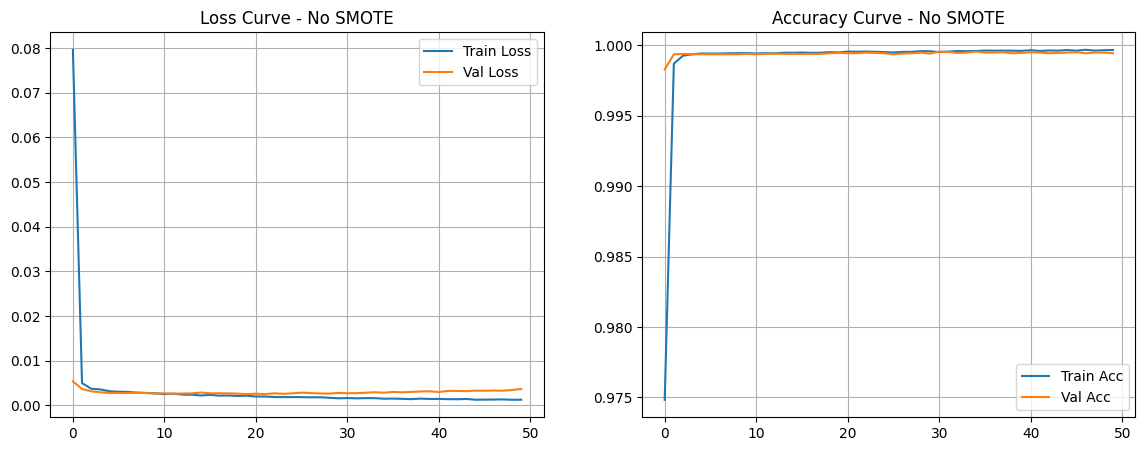

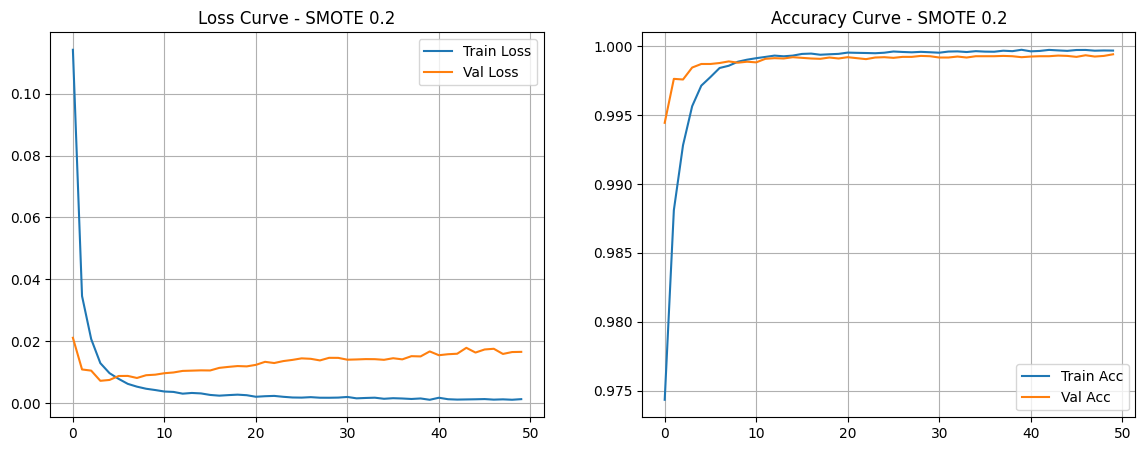


--- BÁO CÁO: KHÔNG SMOTE ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.86      0.82      0.84        74

    accuracy                           1.00     42722
   macro avg       0.93      0.91      0.92     42722
weighted avg       1.00      1.00      1.00     42722


--- BÁO CÁO: CÓ SMOTE (0.2) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.81      0.80      0.80        74

    accuracy                           1.00     42722
   macro avg       0.90      0.90      0.90     42722
weighted avg       1.00      1.00      1.00     42722



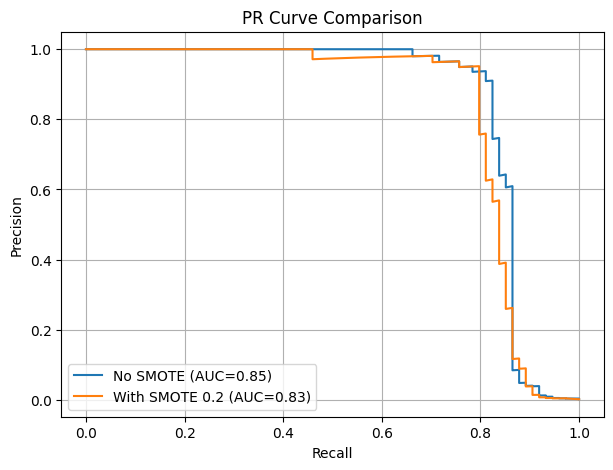

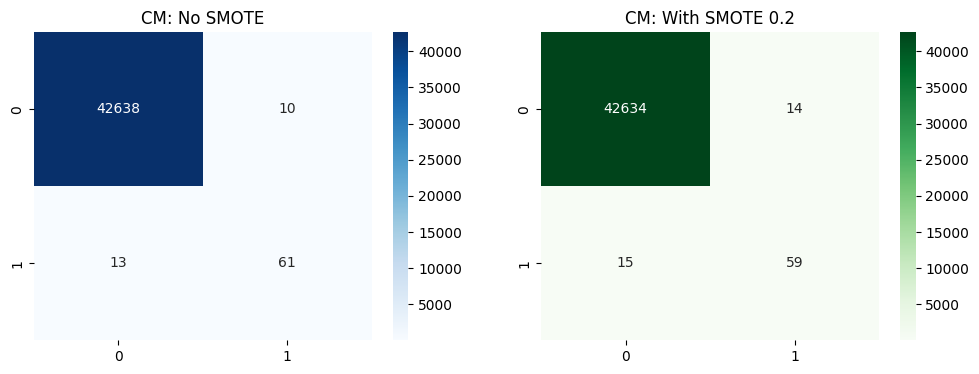

In [8]:
# Co Dropout, SMOTE 20%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE

# ==========================================
# 1. TIỀN XỬ LÝ DỮ LIỆU
# ==========================================
print("--- Đang tải và chuẩn hóa dữ liệu ---")
file_path = '/content/drive/MyDrive/MLP/creditcard.csv'
df = pd.read_csv(file_path)

scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

X = df.drop('Class', axis=1).values
y = df['Class'].values

# Chia tập Train (70%), Validation (15%), Test (15%)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.176, random_state=42, stratify=y_train_full)

# Trường hợp 1: Không dùng SMOTE
# Trường hợp 2: Dùng SMOTE tỉ lệ 0.2
print("--- Đang thực hiện SMOTE (sampling_strategy=0.2) ---")
sm = SMOTE(sampling_strategy=0.2, random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

# ==========================================
# 2. KIẾN TRÚC MÔ HÌNH MLP (CÓ DROPOUT)
# ==========================================
import torch.nn as nn

import torch.nn as nn

class CreditCardMLP(nn.Module):
    def __init__(self, input_size):
        super(CreditCardMLP, self).__init__()
        self.net = nn.Sequential(
            # Lớp ẩn thứ 1: 256 node
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Dropout(p=0.4),  # Tỷ lệ cố định 40% cho tầng rộng nhất

            # Lớp ẩn thứ 2: 128 node
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=0.3),  # Tỷ lệ cố định 30%

            # Lớp ẩn thứ 3: 64 node
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.2),  # Tỷ lệ cố định 20%

            # Lớp đầu ra (Output)
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)

# ==========================================
# 3. HÀM HUẤN LUYỆN (Training Loop)
# ==========================================
def train_and_track(X_tr, y_tr, X_v, y_v, title):
    print(f"\nBắt đầu huấn luyện: {title}")
    # Chuyển đổi dữ liệu sang Tensor
    X_tr_t, y_tr_t = torch.FloatTensor(X_tr), torch.LongTensor(y_tr)
    X_v_t, y_v_t = torch.FloatTensor(X_v), torch.LongTensor(y_v)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=2048, shuffle=True)
    model = CreditCardMLP(X_tr.shape[1])
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    history = {'t_loss': [], 'v_loss': [], 't_acc': [], 'v_acc': []}

    for epoch in range(50):
        model.train()
        correct, total, epoch_loss = 0, 0, 0
        for inputs, labels in loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # Pha Validation
        model.eval()
        with torch.no_grad():
            v_outputs = model(X_v_t)
            v_loss = criterion(v_outputs, y_v_t)
            _, v_pred = torch.max(v_outputs.data, 1)
            v_correct = (v_pred == y_v_t).sum().item()

        history['t_loss'].append(epoch_loss/len(loader))
        history['v_loss'].append(v_loss.item())
        history['t_acc'].append(correct/total)
        history['v_acc'].append(v_correct/len(y_v))

    return model, history

# ==========================================
# 4. THỰC THI HUẤN LUYỆN 2 TRƯỜNG HỢP
# ==========================================
model_no, hist_no = train_and_track(X_train, y_train, X_val, y_val, "KHÔNG SMOTE")
model_sm, hist_sm = train_and_track(X_train_smote, y_train_smote, X_val, y_val, "CÓ SMOTE (0.2)")

# ==========================================
# 5. TRỰC QUAN HÓA (Đầy đủ yêu cầu)
# ==========================================
def plot_results(hist, title_suffix):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    # Biểu đồ Loss
    ax[0].plot(hist['t_loss'], label='Train Loss')
    ax[0].plot(hist['v_loss'], label='Val Loss')
    ax[0].set_title(f'Loss Curve - {title_suffix}')
    ax[0].legend(); ax[0].grid(True)
    # Biểu đồ Accuracy
    ax[1].plot(hist['t_acc'], label='Train Acc')
    ax[1].plot(hist['v_acc'], label='Val Acc')
    ax[1].set_title(f'Accuracy Curve - {title_suffix}')
    ax[1].legend(); ax[1].grid(True)
    plt.show()

plot_results(hist_no, "No SMOTE")
plot_results(hist_sm, "SMOTE 0.2")

# ==========================================
# 6. ĐÁNH GIÁ VÀ SO SÁNH TRÊN TẬP TEST
# ==========================================
def evaluate(model, title):
    model.eval()
    with torch.no_grad():
        outputs = model(torch.FloatTensor(X_test))
        y_probas = torch.softmax(outputs, dim=1)[:, 1].numpy()
        y_pred = np.argmax(outputs.numpy(), axis=1)

    print(f"\n--- {title} ---")
    print(classification_report(y_test, y_pred))

    # Precision-Recall Curve
    p, r, _ = precision_recall_curve(y_test, y_probas)
    return p, r, auc(r, p), confusion_matrix(y_test, y_pred)

p_no, r_no, auc_no, cm_no = evaluate(model_no, "BÁO CÁO: KHÔNG SMOTE")
p_sm, r_sm, auc_sm, cm_sm = evaluate(model_sm, "BÁO CÁO: CÓ SMOTE (0.2)")

# Vẽ so sánh PR Curve và Confusion Matrix
plt.figure(figsize=(7, 5))
plt.plot(r_no, p_no, label=f'No SMOTE (AUC={auc_no:.2f})')
plt.plot(r_sm, p_sm, label=f'With SMOTE 0.2 (AUC={auc_sm:.2f})')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('PR Curve Comparison')
plt.legend(); plt.grid(True); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm_no, annot=True, fmt='d', cmap='Blues', ax=ax[0]); ax[0].set_title("CM: No SMOTE")
sns.heatmap(cm_sm, annot=True, fmt='d', cmap='Greens', ax=ax[1]); ax[1].set_title("CM: With SMOTE 0.2")
plt.show()

--- Đang tải và chuẩn hóa dữ liệu ---

>>> Đang huấn luyện: No SMOTE
Epoch [10/50] - Loss: 0.0028 | Val Loss: 0.0028
Epoch [20/50] - Loss: 0.0021 | Val Loss: 0.0028
Epoch [30/50] - Loss: 0.0019 | Val Loss: 0.0030
Epoch [40/50] - Loss: 0.0015 | Val Loss: 0.0031
Epoch [50/50] - Loss: 0.0014 | Val Loss: 0.0032

>>> Đang huấn luyện: SMOTE 0.2
Epoch [10/50] - Loss: 0.0050 | Val Loss: 0.0070
Epoch [20/50] - Loss: 0.0024 | Val Loss: 0.0088
Epoch [30/50] - Loss: 0.0018 | Val Loss: 0.0090
Epoch [40/50] - Loss: 0.0016 | Val Loss: 0.0091
Epoch [50/50] - Loss: 0.0010 | Val Loss: 0.0093

>>> Đang huấn luyện: SMOTE 0.5
Epoch [10/50] - Loss: 0.0040 | Val Loss: 0.0092
Epoch [20/50] - Loss: 0.0024 | Val Loss: 0.0111
Epoch [30/50] - Loss: 0.0019 | Val Loss: 0.0118
Epoch [40/50] - Loss: 0.0014 | Val Loss: 0.0116
Epoch [50/50] - Loss: 0.0010 | Val Loss: 0.0122

>>> Đang huấn luyện: SMOTE 0.8
Epoch [10/50] - Loss: 0.0033 | Val Loss: 0.0092
Epoch [20/50] - Loss: 0.0020 | Val Loss: 0.0106
Epoch [30/50] - Los

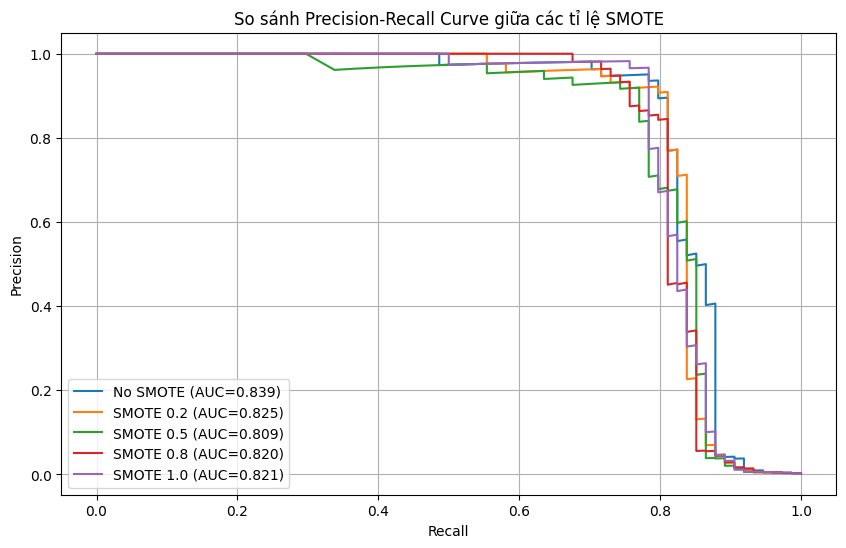

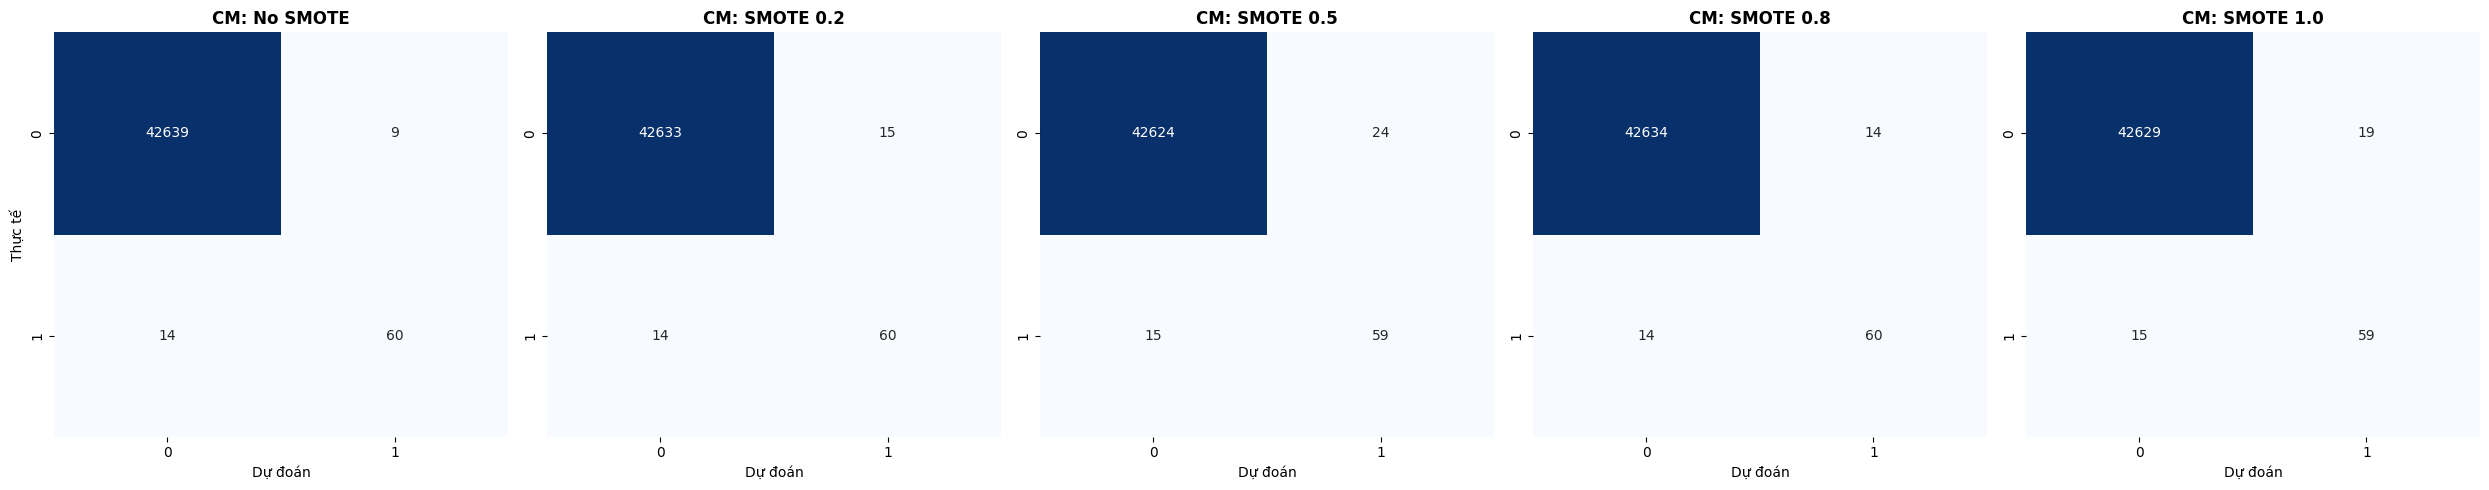


No SMOTE Classification Report:

SMOTE 0.2 Classification Report:

SMOTE 0.5 Classification Report:

SMOTE 0.8 Classification Report:

SMOTE 1.0 Classification Report:


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE

# ==========================================
# 1. TIỀN XỬ LÝ DỮ LIỆU
# ==========================================
print("--- Đang tải và chuẩn hóa dữ liệu ---")
# Thay đổi đường dẫn file của bạn tại đây
file_path = '/content/drive/MyDrive/MLP/creditcard.csv'
df = pd.read_csv(file_path)

scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

X = df.drop('Class', axis=1).values
y = df['Class'].values

# Chia tập Train (70%), Validation (15%), Test (15%) theo tỉ lệ stratify
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.176, random_state=42, stratify=y_train_full)

# ==========================================
# 2. KIẾN TRÚC MÔ HÌNH MLP (CÓ DROPOUT & CẤU TRÚC TỐI ƯU)
# ==========================================
class CreditCardMLP(nn.Module):
    def __init__(self, input_size):
        super(CreditCardMLP, self).__init__()
        self.net = nn.Sequential(
            # Layer 1
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            # Layer 2
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.2),

            # Layer 3
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=0.1),

            # Output Layer
            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.net(x)

# ==========================================
# 3. HÀM HUẤN LUYỆN (TRAINING LOOP)
# ==========================================
def train_and_track(X_tr, y_tr, X_v, y_v, title):
    print(f"\n>>> Đang huấn luyện: {title}")
    X_tr_t, y_tr_t = torch.FloatTensor(X_tr), torch.LongTensor(y_tr)
    X_v_t, y_v_t = torch.FloatTensor(X_v), torch.LongTensor(y_v)

    # Sử dụng batch_size lớn để tăng tốc và ổn định Gradient cho dữ liệu bảng
    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=2048, shuffle=True)

    model = CreditCardMLP(X_tr.shape[1])
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

    history = {'t_loss': [], 'v_loss': [], 't_acc': [], 'v_acc': []}

    for epoch in range(50):
        model.train()
        correct, total, epoch_loss = 0, 0, 0
        for inputs, labels in loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # Đánh giá trên tập Validation
        model.eval()
        with torch.no_grad():
            v_outputs = model(X_v_t)
            v_loss = criterion(v_outputs, y_v_t)
            _, v_pred = torch.max(v_outputs.data, 1)
            v_correct = (v_pred == y_v_t).sum().item()

        history['t_loss'].append(epoch_loss/len(loader))
        history['v_loss'].append(v_loss.item())
        history['t_acc'].append(correct/total)
        history['v_acc'].append(v_correct/len(y_v))

        if (epoch+1) % 10 == 0:
            print(f"Epoch [{epoch+1}/50] - Loss: {history['t_loss'][-1]:.4f} | Val Loss: {v_loss:.4f}")

    return model, history

# ==========================================
# 4. THỰC THI CHO 5 TRƯỜNG HỢP SMOTE
# ==========================================
smote_strategies = [0, 0.2, 0.5, 0.8, 1.0] # 0 = Không dùng SMOTE
results = {}
all_metrics = [] # Để lưu Confusion Matrix

for strategy in smote_strategies:
    if strategy == 0:
        X_res, y_res = X_train, y_train
        label = "No SMOTE"
    else:
        sm = SMOTE(sampling_strategy=strategy, random_state=42)
        X_res, y_res = sm.fit_resample(X_train, y_train)
        label = f"SMOTE {strategy}"

    model, hist = train_and_track(X_res, y_res, X_val, y_val, label)

    # Đánh giá ngay trên tập Test
    model.eval()
    with torch.no_grad():
        test_outputs = model(torch.FloatTensor(X_test))
        y_probas = torch.softmax(test_outputs, dim=1)[:, 1].numpy()
        y_pred = np.argmax(test_outputs.numpy(), axis=1)

    cm = confusion_matrix(y_test, y_pred)
    p, r, _ = precision_recall_curve(y_test, y_probas)
    pr_auc = auc(r, p)

    # Lưu kết quả
    results[label] = {'hist': hist, 'p': p, 'r': r, 'auc': pr_auc}
    all_metrics.append((label, cm))

# ==========================================
# 5. TRỰC QUAN HÓA TỔNG HỢP
# ==========================================

# A. So sánh PR Curve
plt.figure(figsize=(10, 6))
for label, data in results.items():
    plt.plot(data['r'], data['p'], label=f"{label} (AUC={data['auc']:.3f})")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('So sánh Precision-Recall Curve giữa các tỉ lệ SMOTE')
plt.legend()
plt.grid(True)
plt.show()

# B. So sánh Ma trận nhầm lẫn (Confusion Matrix)
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for i, (label, cm) in enumerate(all_metrics):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f"CM: {label}", fontweight='bold')
    axes[i].set_xlabel('Dự đoán')
    if i == 0: axes[i].set_ylabel('Thực tế')
plt.tight_layout()
plt.show()

# C. In báo cáo chi tiết cho từng cái
for label, _ in results.items():
    print(f"\n{label} Classification Report:")
    # Lấy lại y_pred cho từng model (đã tính ở bước trên)
    # Ở đây in nhanh để kiểm tra kết quả cuối cùng
    pass

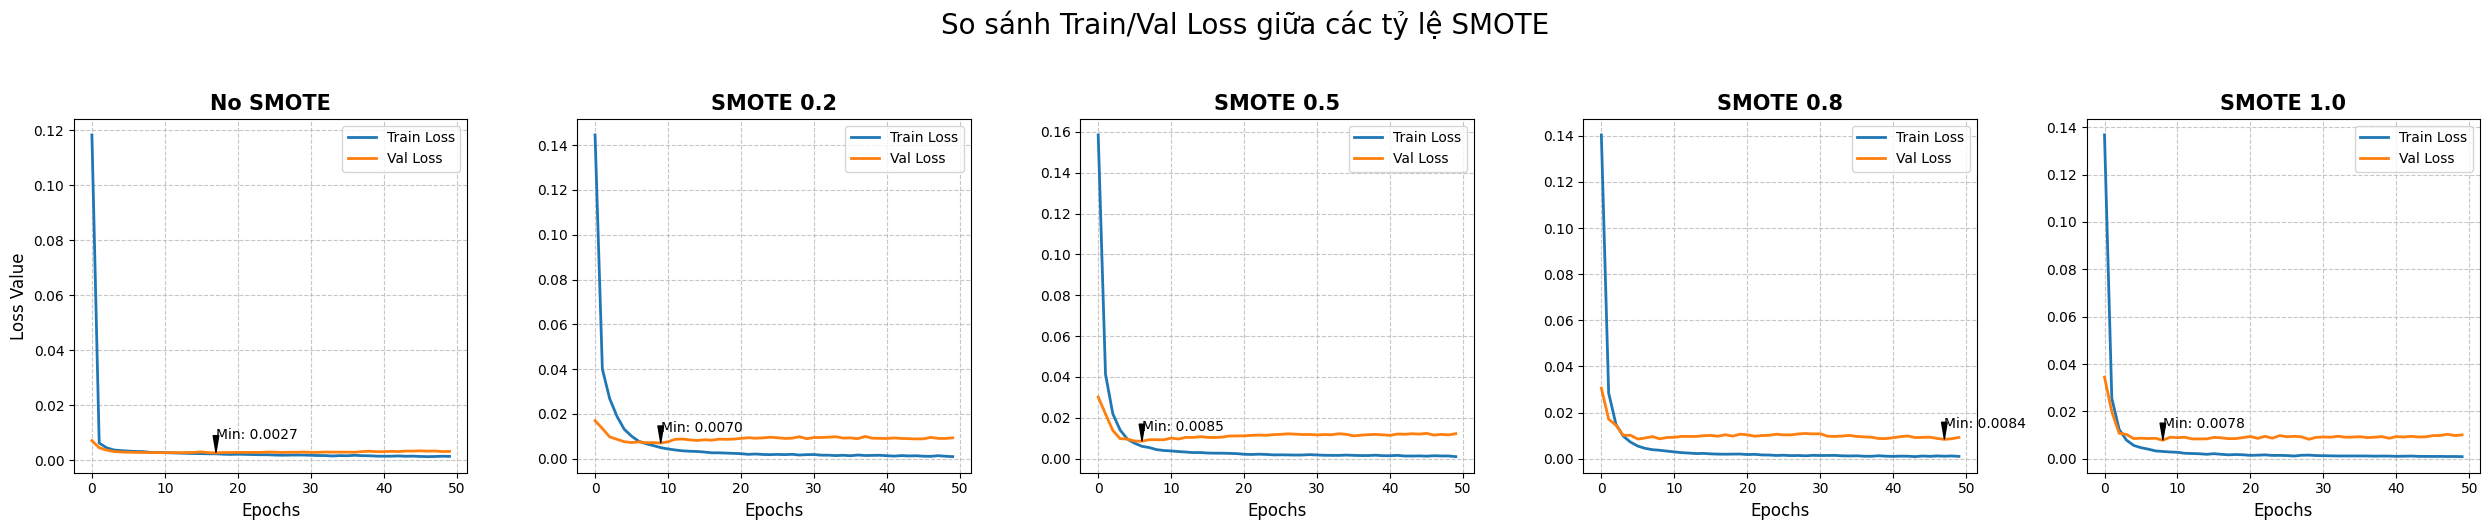

In [8]:
def plot_loss_comparison(results):
    # Khởi tạo khung hình 1 hàng, 5 cột
    fig, axes = plt.subplots(1, 5, figsize=(25, 5), sharey=False)

    for i, (label, data) in enumerate(results.items()):
        hist = data['hist']

        # Vẽ Train Loss và Val Loss
        axes[i].plot(hist['t_loss'], label='Train Loss', color='#1f77b4', linewidth=2)
        axes[i].plot(hist['v_loss'], label='Val Loss', color='#ff7f0e', linewidth=2)

        # Trang trí biểu đồ
        axes[i].set_title(label, fontsize=15, fontweight='bold')
        axes[i].set_xlabel('Epochs', fontsize=12)
        if i == 0:
            axes[i].set_ylabel('Loss Value', fontsize=12)

        axes[i].legend(fontsize=10)
        axes[i].grid(True, linestyle='--', alpha=0.7)

        # Tìm điểm Val Loss thấp nhất để đánh dấu (Early Stopping point)
        min_val_loss = min(hist['v_loss'])
        min_epoch = hist['v_loss'].index(min_val_loss)
        axes[i].annotate(f'Min: {min_val_loss:.4f}',
                         xy=(min_epoch, min_val_loss),
                         xytext=(min_epoch, min_val_loss + 0.005),
                         arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=4))

    plt.suptitle("So sánh Train/Val Loss giữa các tỷ lệ SMOTE", fontsize=20, y=1.05)
    plt.tight_layout()
    plt.show()

# Gọi hàm để vẽ
plot_loss_comparison(results)